<a href="https://colab.research.google.com/github/ashrithapydimalla/DVLab-B_23A91A61B8/blob/main/kidney_Disease_Prediction_with_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
sample = pd.read_csv("kidney_disease_dataset.csv")
sample

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status,Dialysis_Needed
0,71,0.30,40.9,0,1,46.8,1622.0,1,0
1,34,1.79,17.1,0,0,43.8,1428.0,1,0
2,80,2.67,15.0,0,1,78.2,1015.0,1,0
3,40,0.97,31.1,0,1,92.8,1276.0,1,0
4,43,2.05,22.8,1,1,62.2,1154.0,0,0
...,...,...,...,...,...,...,...,...,...
2299,89,1.11,5.0,1,0,55.1,1344.0,1,0
2300,89,0.30,5.0,0,0,47.5,2156.0,1,0
2301,84,0.30,7.3,1,0,120.0,1353.0,0,0
2302,24,1.58,26.4,1,0,75.6,1067.0,0,0


In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2304 non-null   int64  
 1   Creatinine_Level  2304 non-null   float64
 2   BUN               2304 non-null   float64
 3   Diabetes          2304 non-null   int64  
 4   Hypertension      2304 non-null   int64  
 5   GFR               2304 non-null   float64
 6   Urine_Output      2304 non-null   float64
 7   CKD_Status        2304 non-null   int64  
 8   Dialysis_Needed   2304 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 162.1 KB


In [ ]:
sample.isnull().sum()

,0
Age,0
Creatinine_Level,0
BUN,0
Diabetes,0
Hypertension,0
GFR,0
Urine_Output,0
CKD_Status,0
Dialysis_Needed,0


In [ ]:
sample.sum()

,0
Age,124783.00
Creatinine_Level,3008.19
BUN,43346.70
Diabetes,937.00
Hypertension,1148.00
GFR,158869.70
Urine_Output,3016373.00
CKD_Status,1172.00
Dialysis_Needed,31.00


In [ ]:
sample.describe()

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status,Dialysis_Needed
count,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000
mean,54.159288,1.305638,18.813672,0.406684,0.498264,68.953863,1309.189670,0.508681,0.013455
std,20.513729,0.789594,10.508358,0.491322,0.500106,24.660191,491.951914,0.500033,0.115237
min,20.000000,0.300000,5.000000,0.000000,0.000000,5.000000,100.000000,0.000000,0.000000
25%,36.000000,0.620000,9.975000,0.000000,0.000000,51.300000,967.750000,0.000000,0.000000
50%,54.000000,1.240000,18.200000,0.000000,0.000000,69.150000,1295.500000,1.000000,0.000000
75%,72.000000,1.842500,26.000000,1.000000,1.000000,86.300000,1633.500000,1.000000,0.000000
max,90.000000,4.130000,61.900000,1.000000,1.000000,120.000000,2899.000000,1.000000,1.000000


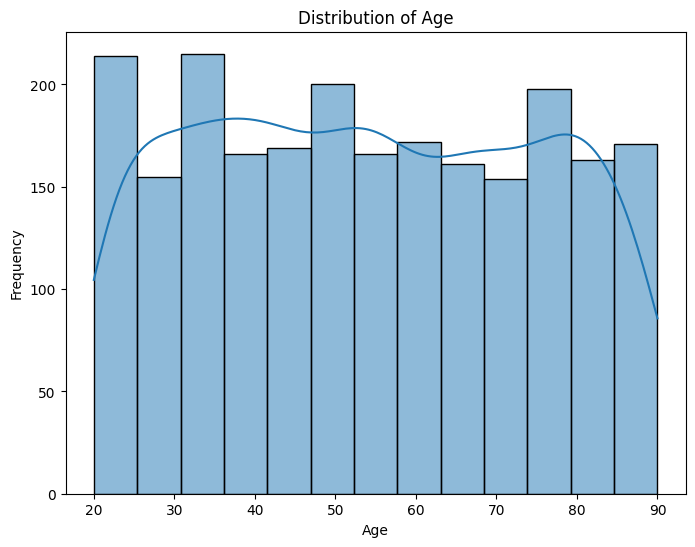

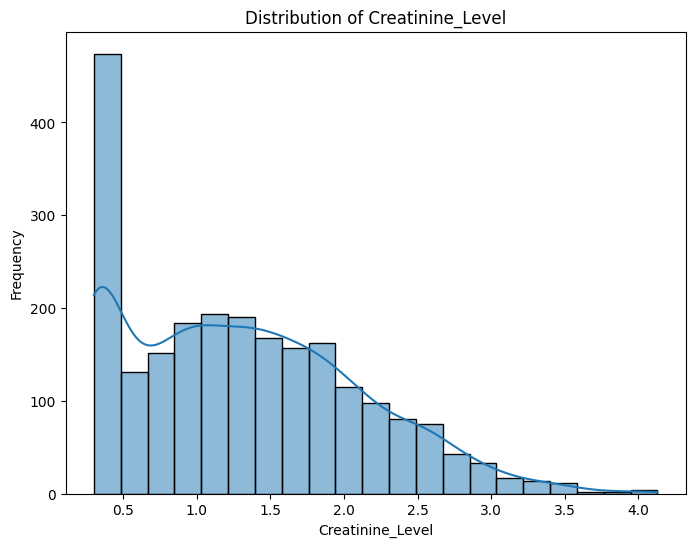

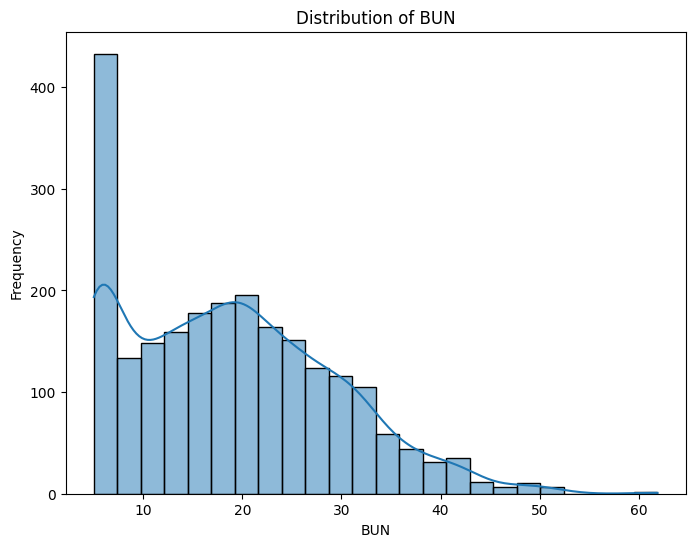

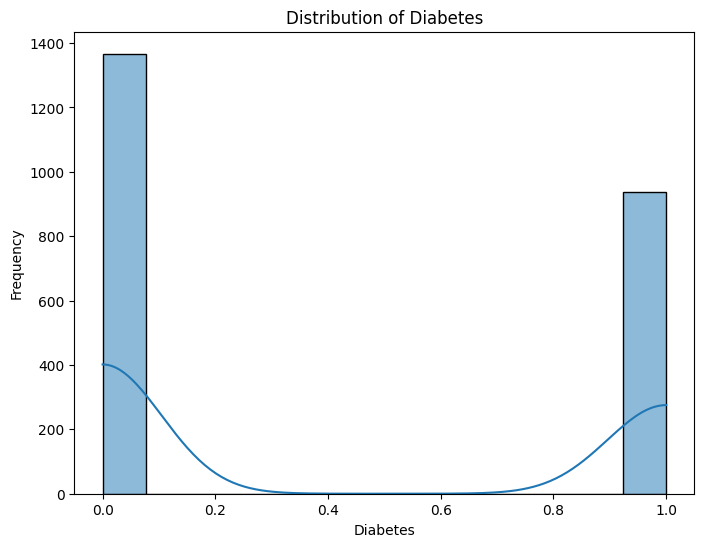

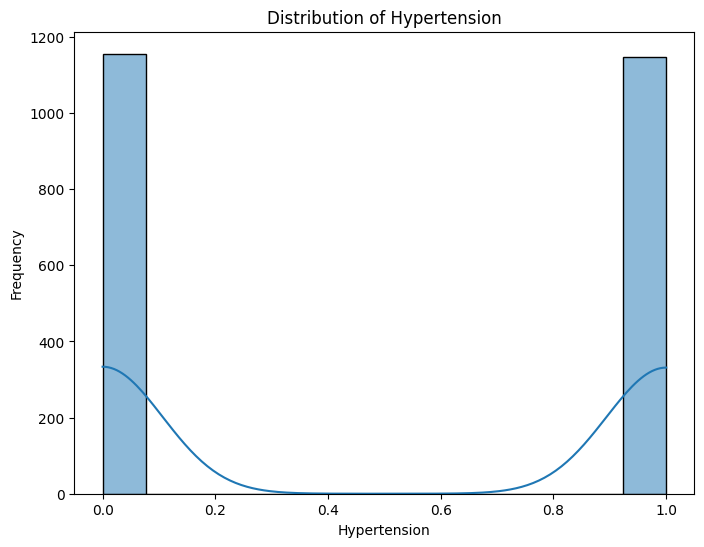

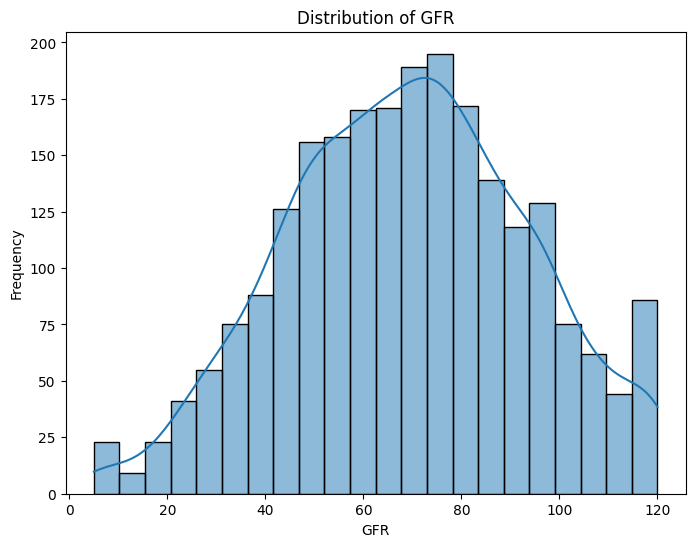

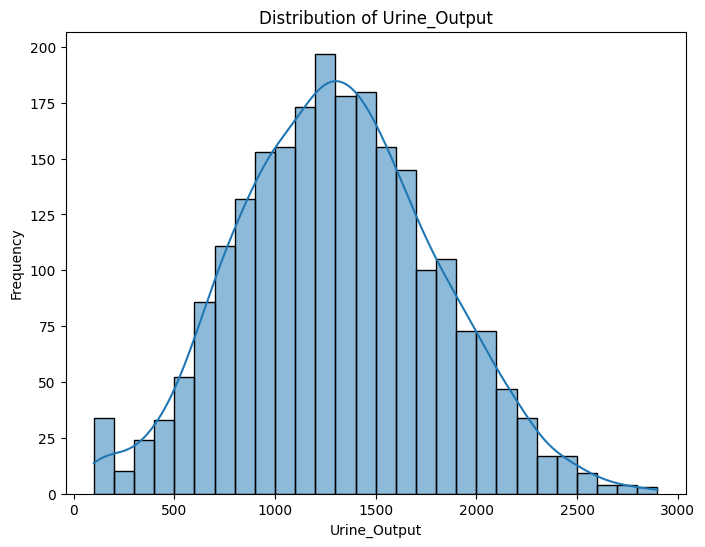

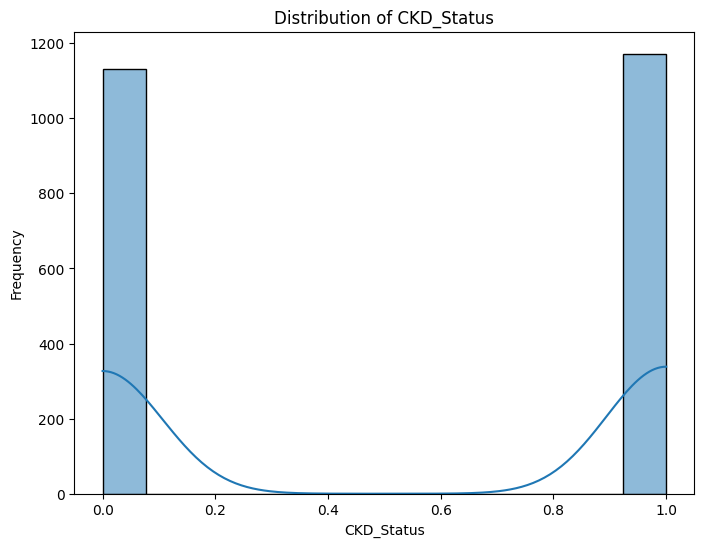

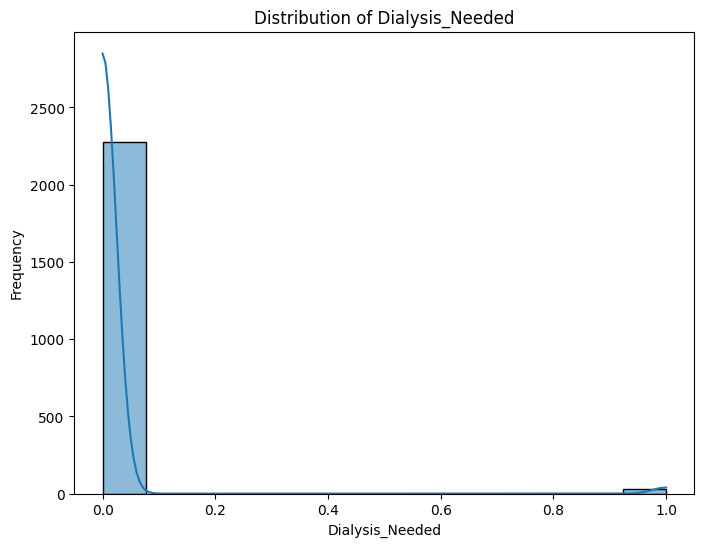

In [ ]:
numerical_cols = sample.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=sample, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Text(0.5, 1.0, 'Correlation heatmap')

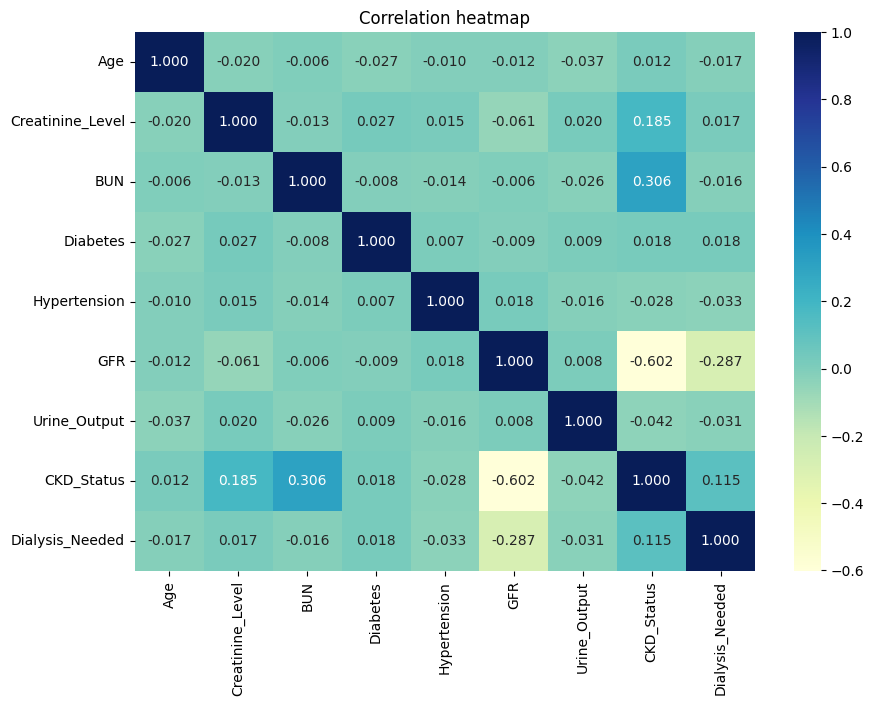

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(sample.corr(), annot = True, fmt=".3f", cmap ="YlGnBu")
plt.title("Correlation heatmap")


In [ ]:
X = sample.drop(["Dialysis_Needed"],axis = 1)
y = sample["Dialysis_Needed"]

In [ ]:
X

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status
0,71,0.30,40.9,0,1,46.8,1622.0,1
1,34,1.79,17.1,0,0,43.8,1428.0,1
2,80,2.67,15.0,0,1,78.2,1015.0,1
3,40,0.97,31.1,0,1,92.8,1276.0,1
4,43,2.05,22.8,1,1,62.2,1154.0,0
...,...,...,...,...,...,...,...,...
2299,89,1.11,5.0,1,0,55.1,1344.0,1
2300,89,0.30,5.0,0,0,47.5,2156.0,1
2301,84,0.30,7.3,1,0,120.0,1353.0,0
2302,24,1.58,26.4,1,0,75.6,1067.0,0


In [ ]:
y

,Dialysis_Needed
0,0
1,0
2,0
3,0
4,0
...,...
2299,0
2300,0
2301,0
2302,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.22,random_state=42)

In [ ]:
X_train

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status
387,77,1.73,16.3,0,0,63.2,1593.0,0
1385,43,1.38,11.4,1,0,37.0,755.0,1
1112,63,0.86,5.0,1,1,52.4,1063.0,1
605,53,0.30,15.4,1,0,49.2,1256.0,1
1208,80,2.44,29.1,1,1,93.5,982.0,0
...,...,...,...,...,...,...,...,...
1638,83,1.77,12.0,0,1,101.3,100.0,0
1095,81,1.14,6.9,0,1,65.7,1377.0,0
1130,45,2.66,9.4,0,1,35.9,1252.0,1
1294,26,2.95,33.5,0,0,74.9,1937.0,1


In [ ]:
X_test

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status
1640,82,0.30,8.6,0,1,54.2,1402.0,1
508,80,1.34,19.4,1,0,79.3,1629.0,0
1422,83,1.39,20.3,1,1,69.8,917.0,0
44,63,3.49,24.8,1,1,62.6,1032.0,1
1398,90,2.85,17.1,0,1,91.1,785.0,1
...,...,...,...,...,...,...,...,...
1403,43,0.30,19.8,0,1,120.0,979.0,0
409,62,1.39,12.7,1,0,49.3,477.0,1
2280,38,0.84,11.5,1,1,61.2,1907.0,0
2021,43,0.69,20.5,0,1,56.8,1668.0,1


In [ ]:
y_train

,Dialysis_Needed
387,0
1385,0
1112,0
605,0
1208,0
...,...
1638,0
1095,0
1130,0
1294,0


In [ ]:
y_test

,Dialysis_Needed
1640,0
508,0
1422,0
44,0
1398,0
...,...
1403,0
409,0
2280,0
2021,0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.22,random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
training_accuracy = []
testing_accuracy = []
for n_neighbours in range(1,10):
  knn = KNeighborsClassifier(n_neighbors=n_neighbours)
  knn.fit(X_train, y_train)
  training_accuracy.append(knn.score(X_train, y_train))
  testing_accuracy.append(knn.score(X_test, y_test))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=5) # You can choose a different number of neighbors
knn_classifier.fit(X_train, y_train)

print("KNN Classification Training Score:", knn_classifier.score(X_train, y_train))
print("KNN Classification Testing Score:", knn_classifier.score(X_test, y_test))

KNN Classification Training Score: 0.9860879243183083
KNN Classification Testing Score: 0.9881656804733728


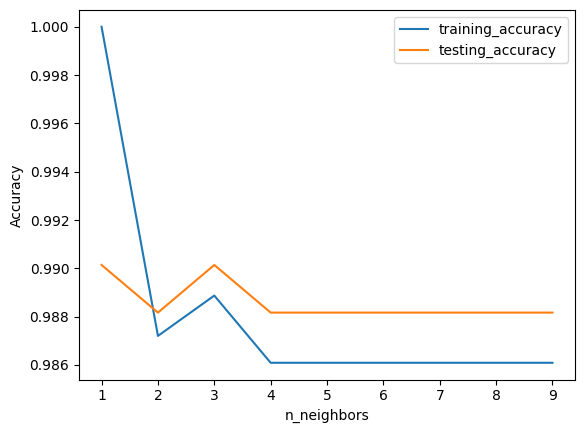

In [ ]:
plt.plot(range(1,10), training_accuracy, label = "training_accuracy")
plt.plot(range(1,10), testing_accuracy, label = "testing_accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
print(knn.score(X_train, y_train), ": training accuracy")
print(knn.score(X_test, y_test), ": testing accuracy")

0.9860879243183083 : training accuracy
0.9881656804733728 : testing accuracy


In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train), ": training accuracy")
print(tree.score(X_test, y_test), ": testing accuracy")

1.0 : training accuracy
1.0 : testing accuracy


In [ ]:
from sklearn.neural_network import MLPClassifier
mlpc = MLPClassifier(random_state=42)
mlpc.fit(X_train, y_train)
print(mlpc.score(X_train, y_train), ": Training accuracy")
print(mlpc.score(X_test, y_test), ": Testing accuracy")

0.993322203672788 : Training accuracy
0.9940828402366864 : Testing accuracy


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score
y_pred = mlpc.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.9940828402366864
F1 Score: 0.6666666666666666
Confusion Matrix:
 [[501   0]
 [  3   3]]
Recall: 0.5
Precision: 1.0
